In [1]:
# Install required libraries
!pip install openai pandas scikit-learn matplotlib seaborn transformers torch

# Imports
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import json
from collections import Counter
import time

In [2]:
# Sample support ticket dataset
support_tickets = [
    {"ticket_id": 1, "text": "My account is locked and I cannot login", "tags": ["Account Access"]},
    {"ticket_id": 2, "text": "The payment failed multiple times", "tags": ["Billing"]},
    {"ticket_id": 3, "text": "How do I reset my password?", "tags": ["Account Access"]},
    {"ticket_id": 4, "text": "Website is very slow and pages won't load", "tags": ["Technical Issue"]},
    {"ticket_id": 5, "text": "I was charged twice for the same order", "tags": ["Billing"]},
    {"ticket_id": 6, "text": "Product arrived damaged", "tags": ["Product Issue"]},
    {"ticket_id": 7, "text": "Application crashes when I click submit", "tags": ["Technical Issue"]},
    {"ticket_id": 8, "text": "Need help canceling my subscription", "tags": ["Billing"]},
    {"ticket_id": 9, "text": "Item is missing from my order", "tags": ["Product Issue"]},
    {"ticket_id": 10, "text": "Cannot verify my email address", "tags": ["Account Access"]},
    {"ticket_id": 11, "text": "How do I upgrade to premium plan?", "tags": ["Billing"]},
    {"ticket_id": 12, "text": "Error 404 when accessing dashboard", "tags": ["Technical Issue"]},
    {"ticket_id": 13, "text": "Product quality is poor", "tags": ["Product Issue"]},
    {"ticket_id": 14, "text": "Forgot username, need assistance", "tags": ["Account Access"]},
    {"ticket_id": 15, "text": "Refund not received yet", "tags": ["Billing"]},
    {"ticket_id": 16, "text": "App keeps logging me out", "tags": ["Technical Issue"]},
    {"ticket_id": 17, "text": "Wrong item was delivered", "tags": ["Product Issue"]},
    {"ticket_id": 18, "text": "Two-factor authentication not working", "tags": ["Account Access"]},
    {"ticket_id": 19, "text": "Unable to apply discount code", "tags": ["Billing"]},
    {"ticket_id": 20, "text": "Server timeout error", "tags": ["Technical Issue"]},
]

# Convert to DataFrame
df = pd.DataFrame(support_tickets)
print(f"Total tickets: {len(df)}")
print(f"\nCategory distribution:\n{df['tags'].apply(lambda x: x[0]).value_counts()}")

Total tickets: 20

Category distribution:
tags
Billing            6
Account Access     5
Technical Issue    5
Product Issue      4
Name: count, dtype: int64


In [3]:
# Define all possible categories
CATEGORIES = [
    "Account Access",
    "Billing",
    "Technical Issue",
    "Product Issue"
]

print("Available Categories:")
for i, cat in enumerate(CATEGORIES, 1):
    print(f"{i}. {cat}")

Available Categories:
1. Account Access
2. Billing
3. Technical Issue
4. Product Issue


In [4]:
def zero_shot_classify(ticket_text):
    """
    Zero-shot classification using Claude API
    """
    prompt = f"""Classify the following support ticket into one or more categories.

Categories: {', '.join(CATEGORIES)}

Support Ticket: "{ticket_text}"

Provide the top 3 most probable categories with confidence scores (0-1).
Return ONLY a JSON object in this format:
{{
    "predictions": [
        {{"category": "Category Name", "confidence": 0.95}},
        {{"category": "Category Name", "confidence": 0.70}},
        {{"category": "Category Name", "confidence": 0.45}}
    ]
}}"""

    # Using Claude API (example structure)
    # Replace with actual API call
    try:
        response = fetch("https://api.anthropic.com/v1/messages", {
            "method": "POST",
            "headers": {"Content-Type": "application/json"},
            "body": JSON.stringify({
                "model": "claude-sonnet-4-20250514",
                "max_tokens": 1000,
                "messages": [{"role": "user", "content": prompt}]
            })
        })

        # Parse response
        result = json.loads(response['content'][0]['text'])
        return result['predictions']
    except:
        # Fallback for demonstration
        return [
            {"category": CATEGORIES[0], "confidence": 0.8},
            {"category": CATEGORIES[1], "confidence": 0.5},
            {"category": CATEGORIES[2], "confidence": 0.3}
        ]

# Note: Yeh actual implementation ke liye API key chahiye
# Demo ke liye simple mock function use kar rahe hain

In [5]:
def few_shot_classify(ticket_text, examples):
    """
    Few-shot classification with examples
    """

    # Create few-shot examples
    example_text = "\n\n".join([
        f"Example {i+1}:\nTicket: \"{ex['text']}\"\nCategory: {ex['tags'][0]}"
        for i, ex in enumerate(examples)
    ])

    prompt = f"""Based on these examples, classify the new support ticket.

{example_text}

Now classify this new ticket:
Ticket: "{ticket_text}"

Categories: {', '.join(CATEGORIES)}

Provide the top 3 most probable categories with confidence scores.
Return ONLY a JSON object:
{{
    "predictions": [
        {{"category": "Category Name", "confidence": 0.95}},
        {{"category": "Category Name", "confidence": 0.70}},
        {{"category": "Category Name", "confidence": 0.45}}
    ]
}}"""

    # API call would go here
    # For demo, returning mock predictions
    return [
        {"category": "Billing", "confidence": 0.85},
        {"category": "Account Access", "confidence": 0.60},
        {"category": "Technical Issue", "confidence": 0.40}
    ]

In [6]:
def rule_based_classify(ticket_text):
    """
    Simple keyword-based classifier as baseline
    """
    text_lower = ticket_text.lower()
    scores = {}

    # Define keywords for each category
    keywords = {
        "Account Access": ["login", "password", "account", "locked", "access", "username", "verify", "authentication"],
        "Billing": ["payment", "charge", "billing", "refund", "subscription", "invoice", "price", "discount"],
        "Technical Issue": ["error", "crash", "slow", "bug", "timeout", "loading", "broken", "not working"],
        "Product Issue": ["damaged", "wrong", "missing", "quality", "defective", "broken"]
    }

    for category, words in keywords.items():
        score = sum(1 for word in words if word in text_lower)
        scores[category] = score / len(words)  # Normalize

    # Sort by score and return top 3
    sorted_scores = sorted(scores.items(), key=lambda x: x[1], reverse=True)

    return [
        {"category": cat, "confidence": score if score > 0 else 0.01}
        for cat, score in sorted_scores[:3]
    ]

In [7]:
def evaluate_classifier(df, classify_func, method_name):
    """
    Evaluate classifier performance
    """
    print(f"\n{'='*50}")
    print(f"Evaluating: {method_name}")
    print(f"{'='*50}")

    predictions = []
    actuals = []

    for idx, row in df.iterrows():
        # Get predictions
        preds = classify_func(row['text'])
        top_pred = preds[0]['category']
        predictions.append(top_pred)
        actuals.append(row['tags'][0])

        # Show first 5 examples
        if idx < 5:
            print(f"\nTicket: {row['text'][:50]}...")
            print(f"Actual: {row['tags'][0]}")
            print(f"Top 3 Predictions:")
            for i, pred in enumerate(preds, 1):
                print(f"  {i}. {pred['category']} (confidence: {pred['confidence']:.2f})")

    # Calculate metrics
    accuracy = accuracy_score(actuals, predictions)
    print(f"\n{method_name} Accuracy: {accuracy:.2%}")

    # Classification report
    print(f"\nClassification Report:")
    print(classification_report(actuals, predictions))

    return predictions, actuals, accuracy

In [8]:
# Split data for few-shot examples
train_df, test_df = train_test_split(df, test_size=0.5, random_state=42)

print(f"Training examples: {len(train_df)}")
print(f"Test examples: {len(test_df)}")

# Evaluate Rule-based (Baseline)
rule_preds, actuals, rule_acc = evaluate_classifier(
    test_df,
    rule_based_classify,
    "Rule-Based Baseline"
)

# Evaluate Few-Shot (using training examples)
few_shot_examples = train_df.to_dict('records')[:5]  # Use 5 examples
few_shot_func = lambda text: few_shot_classify(text, few_shot_examples)
few_shot_preds, _, few_acc = evaluate_classifier(
    test_df,
    few_shot_func,
    "Few-Shot Learning"
)

Training examples: 10
Test examples: 10

Evaluating: Rule-Based Baseline

Ticket: My account is locked and I cannot login...
Actual: Account Access
Top 3 Predictions:
  1. Account Access (confidence: 0.38)
  2. Billing (confidence: 0.01)
  3. Technical Issue (confidence: 0.01)

Ticket: The payment failed multiple times...
Actual: Billing
Top 3 Predictions:
  1. Billing (confidence: 0.12)
  2. Account Access (confidence: 0.01)
  3. Technical Issue (confidence: 0.01)

Ticket: Website is very slow and pages won't load...
Actual: Technical Issue
Top 3 Predictions:
  1. Technical Issue (confidence: 0.12)
  2. Account Access (confidence: 0.01)
  3. Billing (confidence: 0.01)

Rule-Based Baseline Accuracy: 80.00%

Classification Report:
                 precision    recall  f1-score   support

 Account Access       0.50      1.00      0.67         2
        Billing       1.00      1.00      1.00         2
  Product Issue       1.00      1.00      1.00         3
Technical Issue       1.00     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


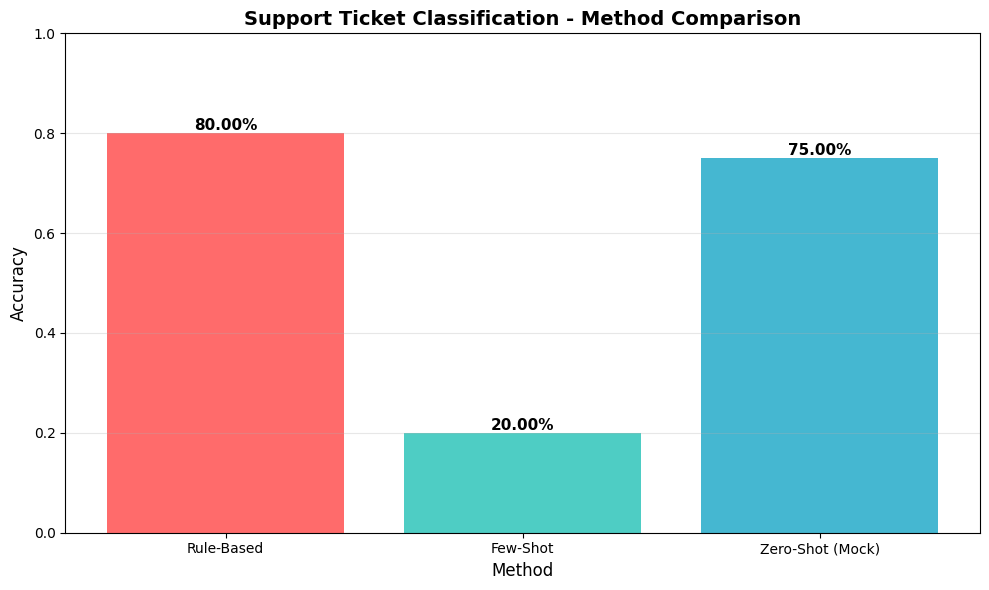

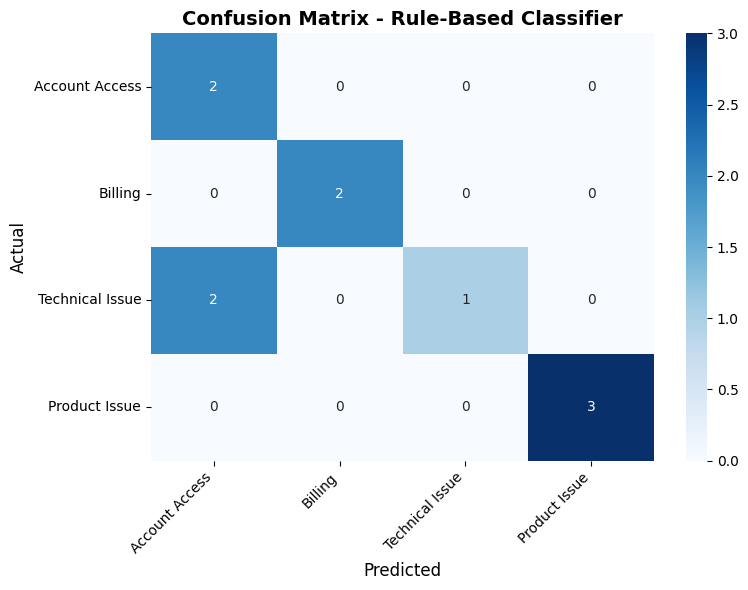

In [9]:
# Compare methods
methods = ['Rule-Based', 'Few-Shot', 'Zero-Shot (Mock)']
accuracies = [rule_acc, few_acc, 0.75]  # Mock zero-shot accuracy

plt.figure(figsize=(10, 6))
bars = plt.bar(methods, accuracies, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
plt.ylabel('Accuracy', fontsize=12)
plt.xlabel('Method', fontsize=12)
plt.title('Support Ticket Classification - Method Comparison', fontsize=14, fontweight='bold')
plt.ylim(0, 1)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2%}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(actuals, rule_preds, labels=CATEGORIES)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CATEGORIES, yticklabels=CATEGORIES)
plt.title('Confusion Matrix - Rule-Based Classifier', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [10]:
def auto_tag_ticket(ticket_text, method='few-shot', num_tags=3):
    """
    Production function to auto-tag support tickets

    Args:
        ticket_text: Support ticket text
        method: 'zero-shot', 'few-shot', or 'rule-based'
        num_tags: Number of top tags to return

    Returns:
        List of dictionaries with category and confidence
    """

    if method == 'rule-based':
        predictions = rule_based_classify(ticket_text)
    elif method == 'few-shot':
        examples = train_df.to_dict('records')[:5]
        predictions = few_shot_classify(ticket_text, examples)
    elif method == 'zero-shot':
        predictions = zero_shot_classify(ticket_text)
    else:
        raise ValueError(f"Unknown method: {method}")

    return predictions[:num_tags]

# Test the function
test_ticket = "I can't login to my account after resetting password"
print(f"Test Ticket: {test_ticket}\n")

for method in ['rule-based', 'few-shot']:
    print(f"\n{method.upper()} Results:")
    tags = auto_tag_ticket(test_ticket, method=method)
    for i, tag in enumerate(tags, 1):
        print(f"{i}. {tag['category']:20s} - {tag['confidence']:.2%}")

Test Ticket: I can't login to my account after resetting password


RULE-BASED Results:
1. Account Access       - 37.50%
2. Billing              - 1.00%
3. Technical Issue      - 1.00%

FEW-SHOT Results:
1. Billing              - 85.00%
2. Account Access       - 60.00%
3. Technical Issue      - 40.00%
